In [1]:
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import make_multilabel_classification
ml_class = make_multilabel_classification()
ml_class

(array([[1., 4., 5., ..., 1., 2., 0.],
        [4., 2., 0., ..., 3., 4., 0.],
        [0., 0., 4., ..., 4., 4., 4.],
        ...,
        [4., 0., 7., ..., 3., 1., 0.],
        [3., 3., 5., ..., 4., 3., 3.],
        [1., 4., 3., ..., 5., 2., 3.]], shape=(100, 20)),
 array([[1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 1, 0],
        [1, 1, 1, 1, 1],
        [1, 0, 0, 1, 1],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [1, 0, 1, 0, 1],
        [1, 0, 0, 0, 1],
        [1, 1, 1, 1, 1],
        [0, 1, 1, 1, 1],
        [1, 0, 0, 0, 1],
        [1, 0, 1, 0, 1],
        [1, 0, 1, 1, 1],
        [0, 1, 0, 1, 0],
        [1, 1, 0, 1, 0],
        [0, 0, 0, 1, 0],
        [1, 0, 1, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 0, 1, 0, 1],
        [0, 0, 1, 0, 0],
        [1, 0, 1, 0, 1],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 1, 0, 1],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 1, 1],
        [

In [10]:
from sklearn.datasets import load_iris
ml_class = load_iris()  # this is a Bunch, like a dictionary

ml_class_df = pd.DataFrame(ml_class["data"] , columns=ml_class["feature_names"])
ml_class_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split , GridSearchCV

def evaluate_preds(y_true , y_pred):
    """

    """
    r2 = r2_score(y_true , y_pred)
    mae = mean_absolute_error(y_true ,y_pred)
    mse = mean_squared_error(y_true , y_pred)
   

    metric_dict ={"r2":round(r2,2),
                  "mae":round(mae,2),
                  "mse":round(mse,2)}

    print(f"The R2 score is :{r2*100:.2f}%")
    print(f"The mean_absolute_error is :{mae:.2f}")
    print(f"The mean_squared_error is :{mse:.2f}")

    return metric_dict
    
np.random.seed(42)

grid ={'n_estimators': [100,200,500],
         'min_samples_split': [6],
         'min_samples_leaf': [1,2],
         'max_features': ['log2','sqrt'],
         'max_depth': [None]}

ml_class_df_shuffled = ml_class_df.sample(frac=1)

x = ml_class_df_shuffled.drop("petal width (cm)" , axis=1)
y = ml_class_df_shuffled["petal width (cm)"]

x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2)

clf = RandomForestRegressor(n_jobs=1)

gs_clf = GridSearchCV(clf,
                      param_grid = grid,
                      cv=5,
                      verbose=2)
gs_clf.fit(x_train ,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   4.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   1.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   3.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   2.7s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, 

,estimator,RandomForestR...ssor(n_jobs=1)
,param_grid,"{'max_depth': [None], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [6], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [21]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
y_preds = gs_clf.predict(x_test)
gs_metrics = evaluate_preds(y_test , y_preds)

The R2 score is :91.89%
The mean_absolute_error is :0.16
The mean_squared_error is :0.04


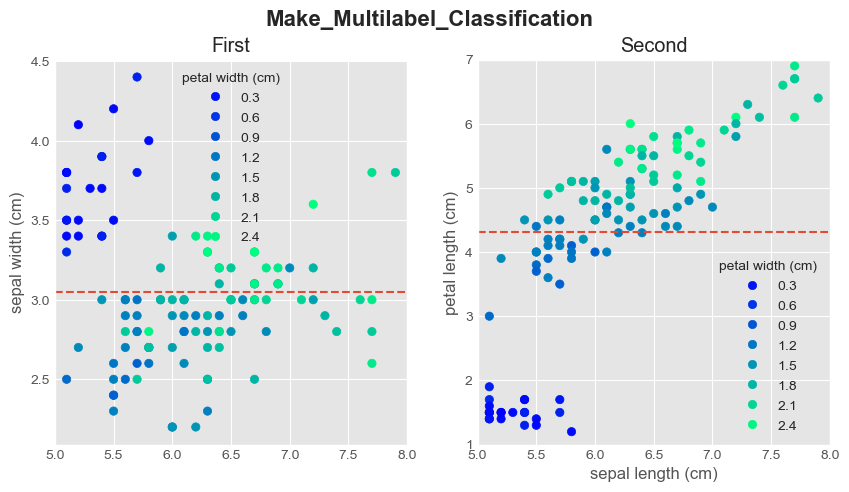

In [30]:
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('ggplot')
fig, (ax0,ax1) = plt.subplots(nrows=1,
                             ncols=2,
                             figsize=(10,5),
                             sharex=True)
## add data to ax0
scatter=ax0.scatter(x=ml_class_df["sepal length (cm)"],
                    y=ml_class_df["sepal width (cm)"],
                    c=ml_class_df["petal width (cm)"],
                   cmap="winter")
## Customize ax0
ax0.set(title="First",
       ylabel="sepal width (cm)")

# change the x axis
ax0.set_xlim([5,8])

## add a legend to ax0
ax0.legend(*scatter.legend_elements(), title="petal width (cm)")

## add a mean line
ax0.axhline(y=ml_class_df["sepal width (cm)"].mean(),
           linestyle='--');

## add data to ax1
scatter=ax1.scatter(x=ml_class_df["sepal length (cm)"],
                    y=ml_class_df["petal length (cm)"],
                    c=ml_class_df["petal width (cm)"],
                   cmap="winter")
##Customize ax1
ax1.set(title="Second",
        xlabel="sepal length (cm)",
        ylabel="petal length (cm)")

# change the x and y axis
ax1.set_xlim([5,8])
ax1.set_ylim([1,7])
## add a legend to ax1
ax1.legend(*scatter.legend_elements(), title="petal width (cm)")
## add a mean line
ax1.axhline(y=ml_class_df["petal length (cm)"].mean(),
            linestyle='--')

## add a title to the figure
fig.suptitle("Make_Multilabel_Classification", fontsize=16 , fontweight="bold")
plt.show()